In [ ]:
%pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-ibm-provider qiskit-ibm-runtime
%pip install qiskit qiskit-ibm-provider --upgrade


Found existing installation: qiskit 1.3.2
Uninstalling qiskit-1.3.2:
  Successfully uninstalled qiskit-1.3.2
Found existing installation: qiskit-terra 0.46.3
Uninstalling qiskit-terra-0.46.3:
  Successfully uninstalled qiskit-terra-0.46.3
Found existing installation: qiskit-aer 0.16.1
Uninstalling qiskit-aer-0.16.1:
  Successfully uninstalled qiskit-aer-0.16.1
Found existing installation: qiskit-ibm-provider 0.11.0
Uninstalling qiskit-ibm-provider-0.11.0:
  Successfully uninstalled qiskit-ibm-provider-0.11.0
Found existing installation: qiskit-ibm-runtime 0.35.0
Uninstalling qiskit-ibm-runtime-0.35.0:
  Successfully uninstalled qiskit-ibm-runtime-0.35.0
  Using cached qiskit-1.3.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached qiskit_ibm_provider-0.11.0-py3-none-any.whl.metadata (7.6 kB)
Using cached qiskit-1.3.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.8 MB)
Using cached qiskit_ibm_provider-0.11.0-py3-none-any.whl (249 kB)


In [ ]:
%pip install qiskit qiskit-ibm-runtime
%pip install 'qiskit[visualization]'
%pip install qiskit-aer
%pip install -q qiskit qiskit-ibm-provider

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.9 MB/s eta 0:00:00
  Using cached qiskit_aer-0.16.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.2 kB)
Using cached qiskit_aer-0.16.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)


In [ ]:
!nvidia-smi

Fri Feb 14 20:24:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import math
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_provider import IBMProvider
from qiskit_aer import AerSimulator, Aer
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


<ipython-input-3-8cc61f51226f>:7: DeprecationWarning: The package qiskit_ibm_provider is being deprecated. Please see https://docs.quantum.ibm.com/api/migration-guides/qiskit-runtime to get instructions on how to migrate to qiskit-ibm-runtime (https://github.com/Qiskit/qiskit-ibm-runtime).
  from qiskit_ibm_provider import IBMProvider


In [ ]:
pi = math.pi
q = QuantumRegister(27,'q')
c = ClassicalRegister(3,'c')
qc = QuantumCircuit(q,c)

In [ ]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token="d6d7e69ec282ec547cb07afcbd9096ded018155024933c2bc73a932e0dba016ae5fc23d4493ae5cf78908d4857dfa9ec56da4eacf24ddb1e3bb63d9efd9bfae0", overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum')
provider = IBMProvider()
backendReal = provider.get_backend('ibm_sherbrooke')
noise_model = NoiseModel.from_backend(backendReal)
backendSim = Aer.get_backend('aer_simulator', device = 'GPU')

#backendSimulator = provider.get_backend('ibmq_qasm_simulator')

target = backendReal.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_qc = pm.run(qc)

Encoding

In [ ]:
qc.cx(q[0], q[9])
qc.cx(q[1], q[10])
qc.cx(q[2], q[11])
qc.cx(q[0], q[18])
qc.cx(q[1], q[19])
qc.cx(q[4], q[20])
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.cx(q[0], q[3])
qc.cx(q[1], q[4])
qc.cx(q[2], q[5])
qc.cx(q[9], q[12])
qc.cx(q[10], q[13])
qc.cx(q[11], q[14])
qc.cx(q[18], q[21])
qc.cx(q[19], q[22])
qc.cx(q[20], q[23])
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[2], q[8])
qc.cx(q[9], q[15])
qc.cx(q[10], q[16])
qc.cx(q[11], q[17])
qc.cx(q[18], q[24])
qc.cx(q[19], q[25])
qc.cx(q[20], q[26])

Grover's Algorithm

In [ ]:
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.x(q[0])
qc.x(q[1])
qc.x(q[2])
qc.h(q[2])
qc.ccx(q[0], q[1], q[2])
qc.x(q[0])
qc.x(q[1])
qc.h(q[2])
qc.h(q[0])
qc.h(q[1])
qc.x(q[2])
qc.x(q[0])
qc.x(q[1])
qc.h(q[2])
qc.x(q[2])
qc.h(q[2])
qc.ccx(q[0], q[1], q[2])
qc.x(q[0])
qc.x(q[1])
qc.h(q[2])
qc.h(q[0])
qc.h(q[1])
qc.x(q[2])
qc.h(q[2])

qc.h(q[3])
qc.h(q[4])
qc.h(q[5])
qc.x(q[3])
qc.x(q[4])
qc.x(q[5])
qc.h(q[5])
qc.ccx(q[3], q[4], q[5])
qc.x(q[3])
qc.x(q[4])
qc.h(q[5])
qc.h(q[3])
qc.h(q[4])
qc.x(q[5])
qc.x(q[3])
qc.x(q[4])
qc.h(q[5])
qc.x(q[5])
qc.h(q[5])
qc.ccx(q[3], q[4], q[5])
qc.x(q[3])
qc.x(q[4])
qc.h(q[5])
qc.h(q[3])
qc.h(q[4])
qc.x(q[5])
qc.h(q[5])

qc.h(q[6])
qc.h(q[7])
qc.h(q[8])
qc.x(q[6])
qc.x(q[7])
qc.x(q[8])
qc.h(q[8])
qc.ccx(q[6], q[7], q[8])
qc.x(q[6])
qc.x(q[7])
qc.h(q[8])
qc.h(q[6])
qc.h(q[7])
qc.x(q[8])
qc.x(q[6])
qc.x(q[7])
qc.h(q[8])
qc.x(q[8])
qc.h(q[8])
qc.ccx(q[6], q[7], q[8])
qc.x(q[6])
qc.x(q[7])
qc.h(q[8])
qc.h(q[6])
qc.h(q[7])
qc.x(q[8])
qc.h(q[8])

qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.x(q[9])
qc.x(q[10])
qc.x(q[11])
qc.h(q[11])
qc.ccx(q[9], q[10], q[11])
qc.x(q[9])
qc.x(q[10])
qc.h(q[11])
qc.h(q[9])
qc.h(q[10])
qc.x(q[11])
qc.x(q[9])
qc.x(q[10])
qc.h(q[11])
qc.x(q[11])
qc.h(q[11])
qc.ccx(q[9], q[10], q[11])
qc.x(q[9])
qc.x(q[10])
qc.h(q[11])
qc.h(q[9])
qc.h(q[10])
qc.x(q[11])
qc.h(q[11])

qc.h(q[12])
qc.h(q[13])
qc.h(q[14])
qc.x(q[12])
qc.x(q[13])
qc.x(q[14])
qc.h(q[14])
qc.ccx(q[12], q[13], q[14])
qc.x(q[12])
qc.x(q[13])
qc.h(q[14])
qc.h(q[12])
qc.h(q[13])
qc.x(q[14])
qc.x(q[12])
qc.x(q[13])
qc.h(q[14])
qc.x(q[14])
qc.h(q[14])
qc.ccx(q[12], q[13], q[14])
qc.x(q[12])
qc.x(q[13])
qc.h(q[14])
qc.h(q[12])
qc.h(q[13])
qc.x(q[14])
qc.h(q[14])

qc.h(q[15])
qc.h(q[16])
qc.h(q[17])
qc.x(q[15])
qc.x(q[16])
qc.x(q[17])
qc.h(q[17])
qc.ccx(q[15], q[16], q[17])
qc.x(q[15])
qc.x(q[16])
qc.h(q[17])
qc.h(q[15])
qc.h(q[16])
qc.x(q[17])
qc.x(q[15])
qc.x(q[16])
qc.h(q[17])
qc.x(q[17])
qc.h(q[17])
qc.ccx(q[15], q[16], q[17])
qc.x(q[15])
qc.x(q[16])
qc.h(q[17])
qc.h(q[15])
qc.h(q[16])
qc.x(q[17])
qc.h(q[17])

qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.x(q[18])
qc.x(q[19])
qc.x(q[20])
qc.h(q[20])
qc.ccx(q[18], q[19], q[20])
qc.x(q[18])
qc.x(q[19])
qc.h(q[20])
qc.h(q[18])
qc.h(q[19])
qc.x(q[20])
qc.x(q[18])
qc.x(q[19])
qc.h(q[20])
qc.x(q[20])
qc.h(q[20])
qc.ccx(q[18], q[19], q[20])
qc.x(q[18])
qc.x(q[19])
qc.h(q[20])
qc.h(q[18])
qc.h(q[19])
qc.x(q[20])
qc.h(q[20])

qc.h(q[21])
qc.h(q[22])
qc.h(q[23])
qc.x(q[21])
qc.x(q[22])
qc.x(q[23])
qc.h(q[23])
qc.ccx(q[21], q[22], q[23])
qc.x(q[21])
qc.x(q[22])
qc.h(q[23])
qc.h(q[21])
qc.h(q[22])
qc.x(q[23])
qc.x(q[21])
qc.x(q[22])
qc.h(q[23])
qc.x(q[23])
qc.h(q[23])
qc.ccx(q[21], q[22], q[23])
qc.x(q[21])
qc.x(q[22])
qc.h(q[23])
qc.h(q[21])
qc.h(q[22])
qc.x(q[23])
qc.h(q[23])

qc.h(q[24])
qc.h(q[25])
qc.h(q[26])
qc.x(q[24])
qc.x(q[25])
qc.x(q[26])
qc.h(q[26])
qc.ccx(q[24], q[25], q[26])
qc.x(q[24])
qc.x(q[25])
qc.h(q[26])
qc.h(q[24])
qc.h(q[25])
qc.x(q[26])
qc.x(q[24])
qc.x(q[25])
qc.h(q[26])
qc.x(q[26])
qc.h(q[26])
qc.ccx(q[24], q[25], q[26])
qc.x(q[24])
qc.x(q[25])
qc.h(q[26])
qc.h(q[24])
qc.h(q[25])
qc.x(q[26])
qc.h(q[26])

Decoding

In [ ]:
qc.cx(q[0], q[3])
qc.cx(q[1], q[4])
qc.cx(q[2], q[5])
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[2], q[8])
qc.cx(q[9], q[12])
qc.cx(q[10], q[13])
qc.cx(q[11], q[14])
qc.cx(q[9], q[15])
qc.cx(q[10], q[16])
qc.cx(q[11], q[17])
qc.cx(q[18], q[21])
qc.cx(q[19], q[22])
qc.cx(q[20], q[23])
qc.cx(q[18], q[24])
qc.cx(q[19], q[25])
qc.cx(q[20], q[26])
qc.ccx(q[6], q[3], q[0])
qc.ccx(q[7], q[4], q[1])
qc.ccx(q[8], q[5], q[2])
qc.ccx(q[15], q[12], q[9])
qc.ccx(q[16], q[13], q[10])
qc.ccx(q[17], q[14], q[11])
qc.ccx(q[24], q[21], q[18])
qc.ccx(q[25], q[22], q[19])
qc.ccx(q[26], q[23], q[20])
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.cx(q[0], q[9])
qc.cx(q[1], q[10])
qc.cx(q[2], q[11])
qc.cx(q[0], q[18])
qc.cx(q[1], q[19])
qc.cx(q[2], q[20])
qc.ccx(q[18], q[9], q[0])
qc.ccx(q[19], q[10], q[1])
qc.ccx(q[20], q[11], q[2])

Measure the logical qubits

In [ ]:
qc.measure(q[0], 0)
qc.measure(q[1], 1)
qc.measure(q[2], 2)

Draw

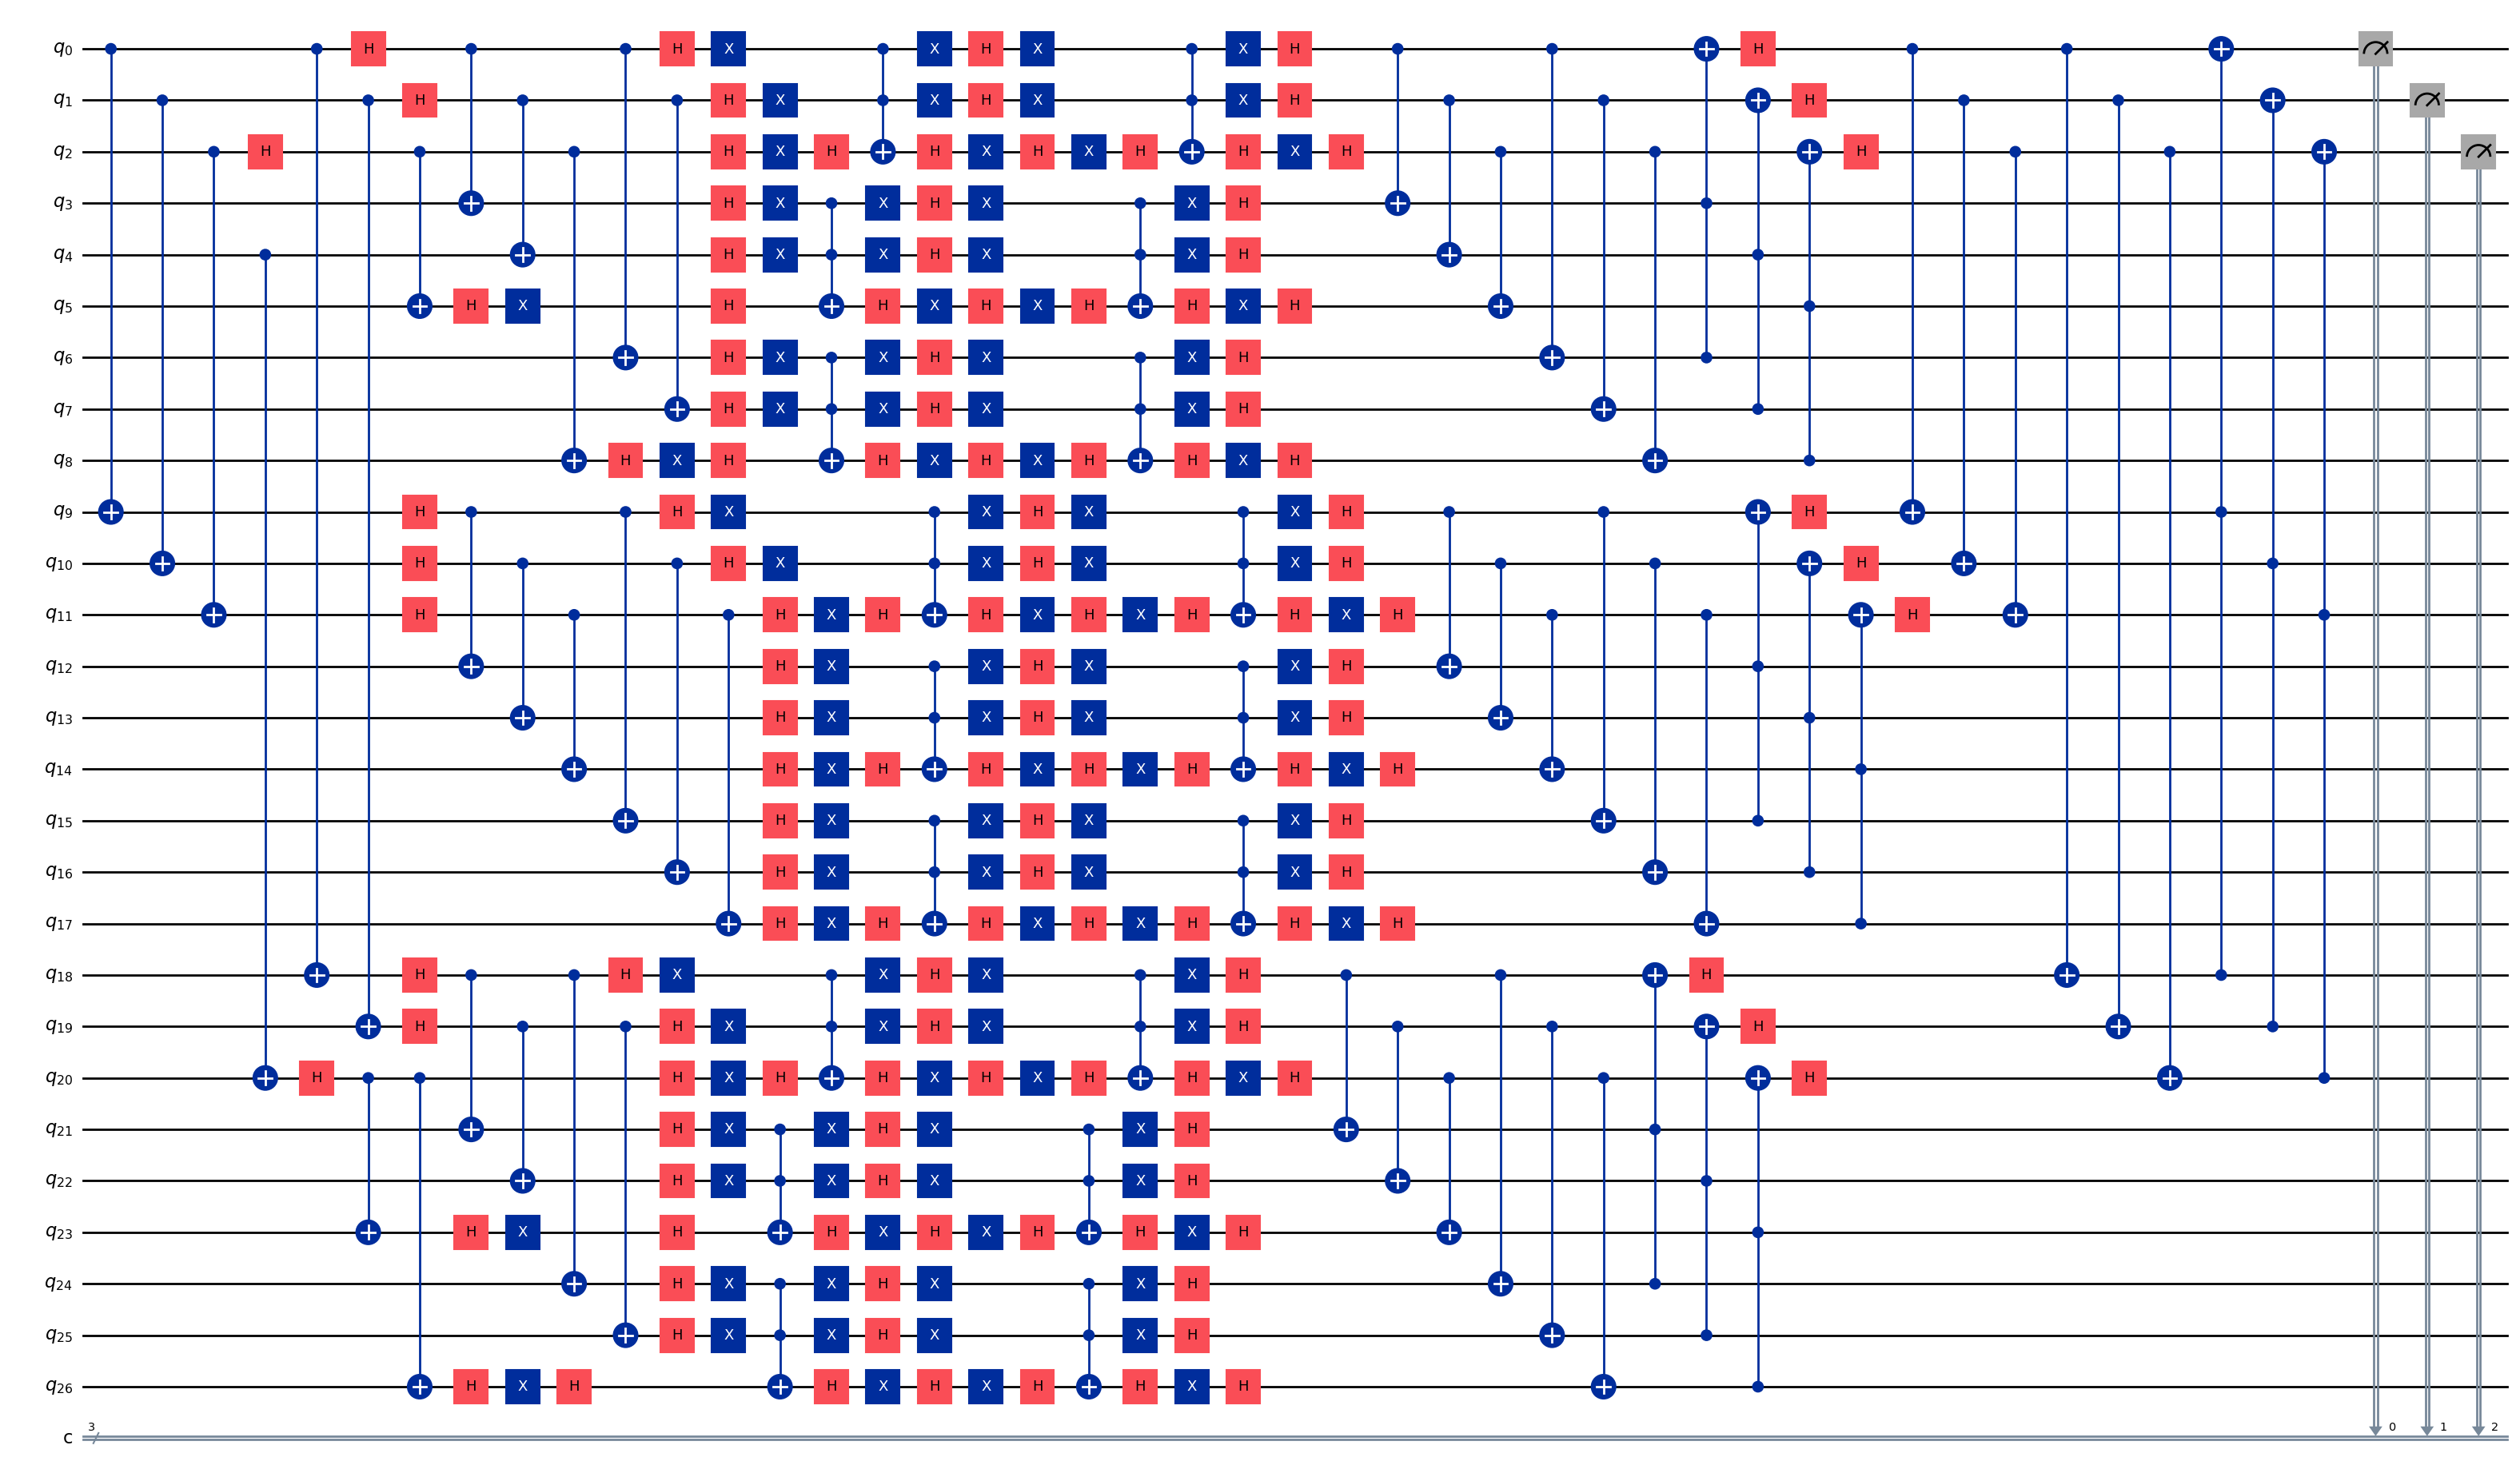

In [ ]:
qc.draw('mpl', fold=False, idle_wires=False)

Optimization

In [ ]:
qc = transpile(qc, backendReal, optimization_level=3)
#qc = transpile(qc, backendSim, optimization_level=3)

Run on IBM Quantum Machine

In [ ]:
sampler = Sampler(mode=backendReal)
sampler.options.default_shots = 10
job = sampler.run([circuit_qc])
results = job.result()

Plot Results

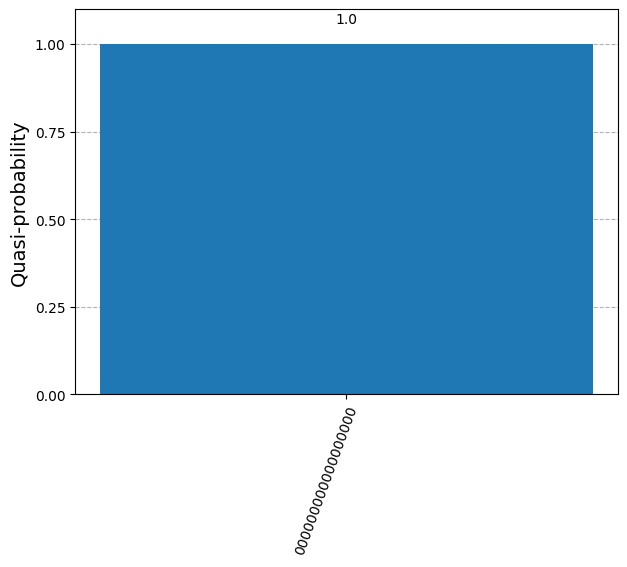

In [ ]:
dist = results[0].data.c.get_counts()
plot_distribution(dist)


Run Simulator

In [ ]:
job=backendSim.run(qc, shots=128, noise_model=noise_model)
result = job.result()
print(result)

#simulator = backendSim(noise_model=noise_model)
#simulator.options.default_shots = 1
#result = simulator.run(qc).result()

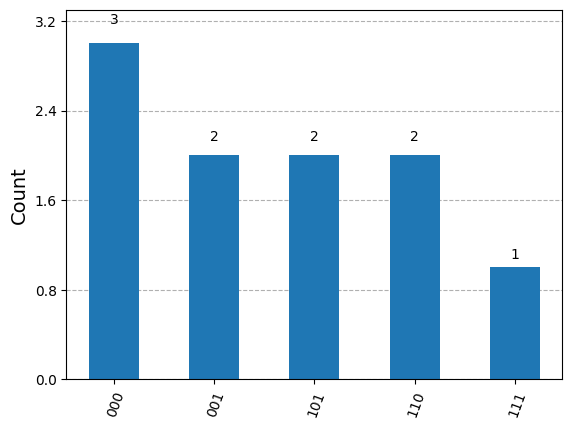

In [ ]:
counts = result.get_counts(qc)
plot_histogram(counts)